In [45]:
import pandas as pd
import numpy as np

In [46]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [47]:
# Display the first 5 rows of the dataset to understand its structure
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [48]:
# Get the number of rows and columns 
df.shape

(6607, 20)

In [49]:
# Display all column names
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [50]:
# Display summary of the dataset including column names, data types, and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [51]:
# Check the number of missing (null) values in each column
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [52]:
# Display detailed information (data types and non-null values) 
# for selected columns in the dataset
df[['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']].info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Teacher_Quality           6529 non-null   str  
 1   Parental_Education_Level  6517 non-null   str  
 2   Distance_from_Home        6540 non-null   str  
dtypes: str(3)
memory usage: 286.1 KB


In [53]:
# Fill missing values in 'Parental_Education_Level' using the most frequent value (mode)
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])

In [54]:
# Fill missing values with mode
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

In [55]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level       0
Distance_from_Home             0
Gender                         0
Exam_Score                     0
dtype: int64

In [56]:
# Count duplicate rows in dataset
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [57]:
# Select categorical columns (object and string types)
cat_cols = df.select_dtypes(include=['object', 'string']).columns

In [58]:
# Clean categorical data: remove spaces and convert to lowercase
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

In [59]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,low,high,no,7,73,low,yes,0,low,medium,public,positive,3,no,high school,near,male,67
1,19,64,low,medium,no,8,59,low,yes,2,medium,medium,public,negative,4,no,college,moderate,female,61
2,24,98,medium,medium,yes,7,91,medium,yes,2,medium,medium,public,neutral,4,no,postgraduate,near,male,74
3,29,89,low,medium,yes,8,98,medium,yes,1,medium,medium,public,negative,4,no,high school,moderate,male,71
4,19,92,medium,medium,yes,6,65,medium,yes,3,medium,high,public,neutral,4,no,college,near,female,70


In [60]:
# Create new feature by combining study hours and tutoring sessions
df['Total_Study_Effort'] = df['Hours_Studied'] + df['Tutoring_Sessions']

In [61]:
# Create feature representing academic strength
df['Academic_Strength'] = df['Previous_Scores'] + df['Hours_Studied']

In [62]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score', 'Total_Study_Effort', 'Academic_Strength'],
      dtype='str')

In [63]:
# Drop unnecessary columns
df = df.drop(['Gender', 'Internet_Access'], axis=1)

In [64]:
df = df.drop(['Distance_from_Home', 'Learning_Disabilities'], axis=1)

In [65]:
print(df.columns)

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Tutoring_Sessions',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Physical_Activity', 'Parental_Education_Level', 'Exam_Score',
       'Total_Study_Effort', 'Academic_Strength'],
      dtype='str')


In [66]:
# Calculate average values of all numerical columns
df.mean(numeric_only=True)

Hours_Studied         19.975329
Attendance            79.977448
Sleep_Hours            7.029060
Previous_Scores       75.070531
Tutoring_Sessions      1.493719
Physical_Activity      2.967610
Exam_Score            67.235659
Total_Study_Effort    21.469048
Academic_Strength     95.045860
dtype: float64

In [67]:
# Get summary statistics (mean, median, std, min, max)
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Total_Study_Effort,Academic_Strength
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659,21.469048,95.045860
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456,6.098438,15.733009
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000,2.000000,54.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000,17.000000,82.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000,21.000000,95.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000,26.000000,108.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000,47.000000,140.000000


In [68]:
# Find correlation between all variables
df.corr(numeric_only=True)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Total_Study_Effort,Academic_Strength
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455,0.979434,0.403506
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072,-0.006842,-0.022248
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022,0.008318,-0.015728
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079,0.021759,0.924720
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525,0.187755,-0.017449
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824,0.008121,-0.008558
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000,0.469162,0.329857
Total_Study_Effort,0.979434,-0.006842,0.008318,0.021759,0.187755,0.008121,0.469162,1.000000,0.392850
Academic_Strength,0.403506,-0.022248,-0.015728,0.924720,-0.017449,-0.008558,0.329857,0.392850,1.000000


In [69]:
# Correlation of all features with Exam_Score
df.corr(numeric_only=True)['Exam_Score'].sort_values(ascending=False)

Exam_Score            1.000000
Attendance            0.581072
Total_Study_Effort    0.469162
Hours_Studied         0.445455
Academic_Strength     0.329857
Previous_Scores       0.175079
Tutoring_Sessions     0.156525
Physical_Activity     0.027824
Sleep_Hours          -0.017022
Name: Exam_Score, dtype: float64

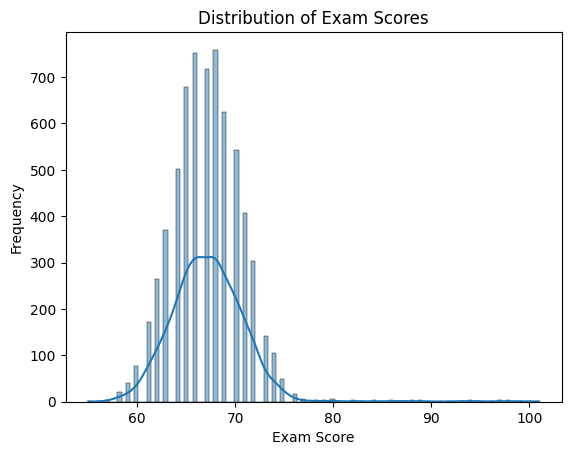

In [70]:
#Histogram chart
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histogram to see distribution of exam scores
sns.histplot(df['Exam_Score'], kde=True)

# Add title and labels
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

# Show plot
plt.show()

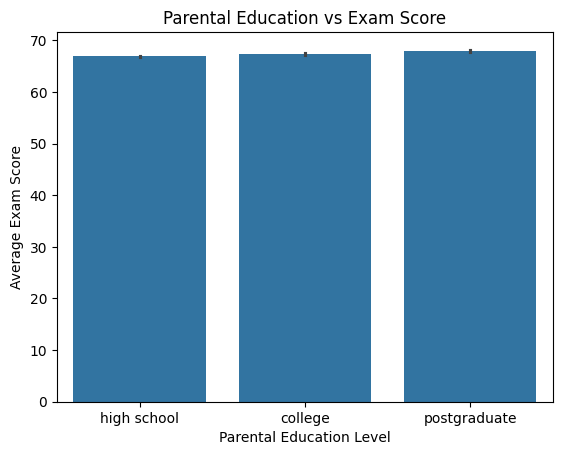

In [71]:
#Bar Chart
# Compare average exam score by parental education level
sns.barplot(x='Parental_Education_Level', y='Exam_Score', data=df)

plt.title("Parental Education vs Exam Score")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Exam Score")

plt.show()

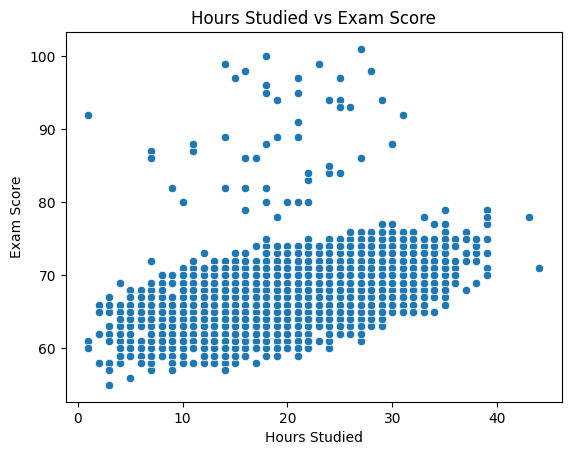

In [72]:
#Scatter Plot
# Analyze relationship between study hours and exam score
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

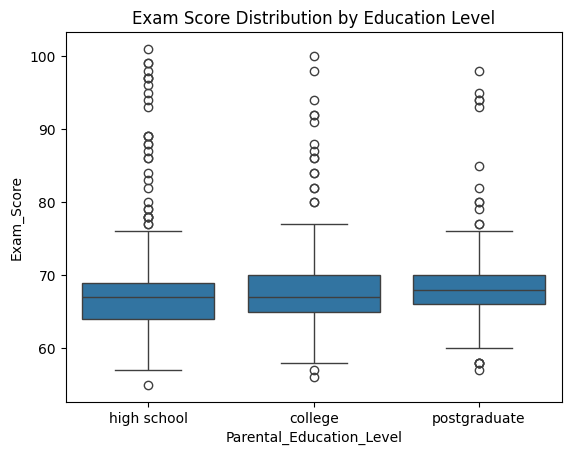

In [73]:
#Box Plot (Outliers + Spread)
# Check distribution and outliers by education level
sns.boxplot(x='Parental_Education_Level', y='Exam_Score', data=df)

plt.title("Exam Score Distribution by Education Level")

plt.show()

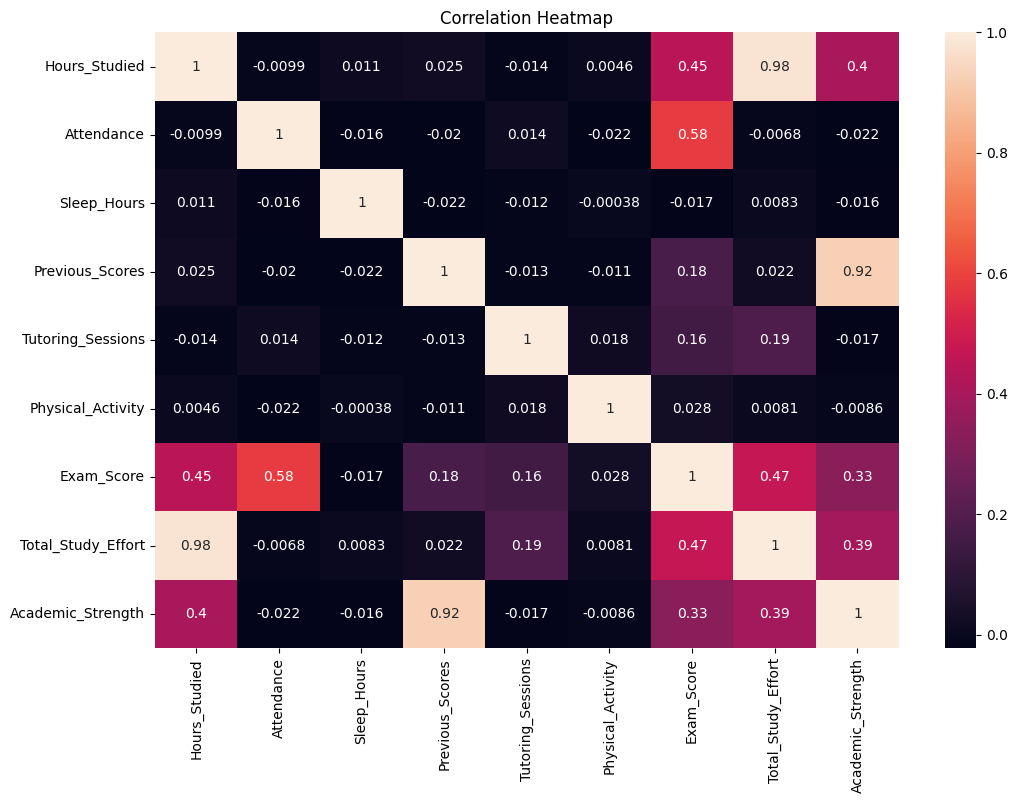

In [74]:
#Correlation Heatmap
# Plot heatmap to visualize correlation between variables
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

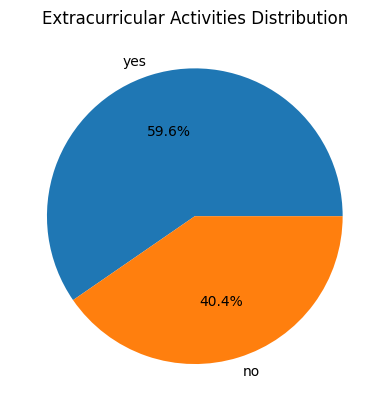

In [75]:
#Pie Chart
# Count values in the column
counts = df['Extracurricular_Activities'].value_counts()

# Plot pie chart
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

# Add title
plt.title("Extracurricular Activities Distribution")

# Show chart
plt.show()

In [76]:
import os
print(os.getcwd())

C:\Users\pkpk3\Documents
